In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
'/content/drive/My Drive/heart.csv'


'/content/drive/My Drive/heart.csv'

In [ ]:
import pandas as pd

# Replace the path with your CSV file's path
csv_file_path = '/content/drive/My Drive/heart.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(csv_file_path)

# Display the DataFrame to verify
df.head()


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
from google.colab import files
uploaded = files.upload()

# Now you can load the uploaded CSV into a DataFrame
import pandas as pd
import io

# Assume the uploaded file name is 'your_file.csv'
df = pd.read_csv(io.BytesIO(uploaded['heart.csv']))

# Display the DataFrame
df.head()


Saving heart.csv to heart.csv


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer


In [ ]:
# Check for missing values
print(df.isnull().sum())

# Use SimpleImputer to fill missing values with the median (for numerical columns)
imputer = SimpleImputer(strategy='median')
df[['column1', 'column2', 'column3']] = imputer.fit_transform(df[['column1', 'column2', 'column3']])

# For categorical columns, you could use the most frequent value (mode)
categorical_columns = ['categorical_column1', 'categorical_column2']
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_columns] = imputer_cat.fit_transform(df[categorical_columns])

# Verify that missing values are handled
print(df.isnull().sum())


age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64


KeyError: "None of [Index(['column1', 'column2', 'column3'], dtype='object')] are in the [columns]"

In [9]:
print(df.columns)


Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='object')


In [10]:
imputer = SimpleImputer(strategy='median')
df[['age', 'sex', 'cp']] = imputer.fit_transform(df[['age', 'sex', 'cp']])


In [11]:
columns_to_impute = ['column1', 'column2', 'column3']
existing_columns = [col for col in columns_to_impute if col in df.columns]
if existing_columns:
    df[existing_columns] = imputer.fit_transform(df[existing_columns])


In [12]:
print(df.isnull().sum())


age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64


In [13]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [14]:
# Load the dataset (replace 'heart.csv' with the actual file path)
df = pd.read_csv('heart.csv')

# Inspect the dataset
print(df.head())


   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  


In [15]:
# Check for missing values
print(df.isnull().sum())

# Impute or drop missing values if required
# For example, impute with median
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df[:] = imputer.fit_transform(df)

# Standardize numerical features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

# Convert back to a DataFrame
scaled_df = pd.DataFrame(scaled_features, columns=df.columns)


age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64


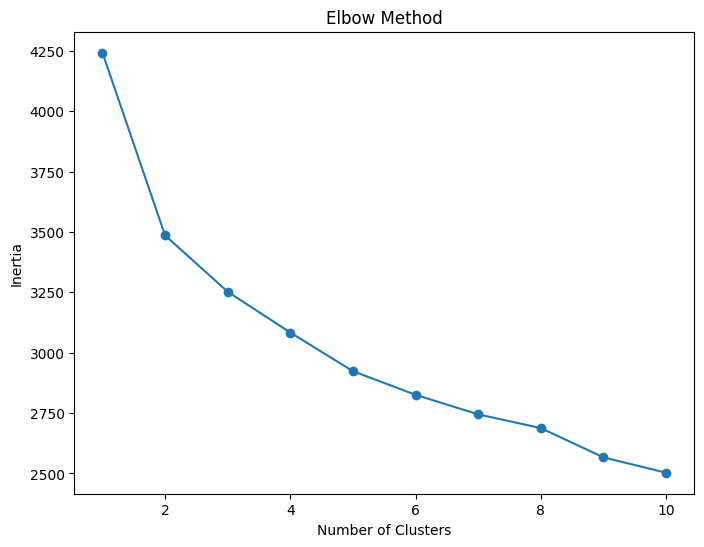

In [16]:
# Perform K-Means with varying cluster numbers
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=3, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()


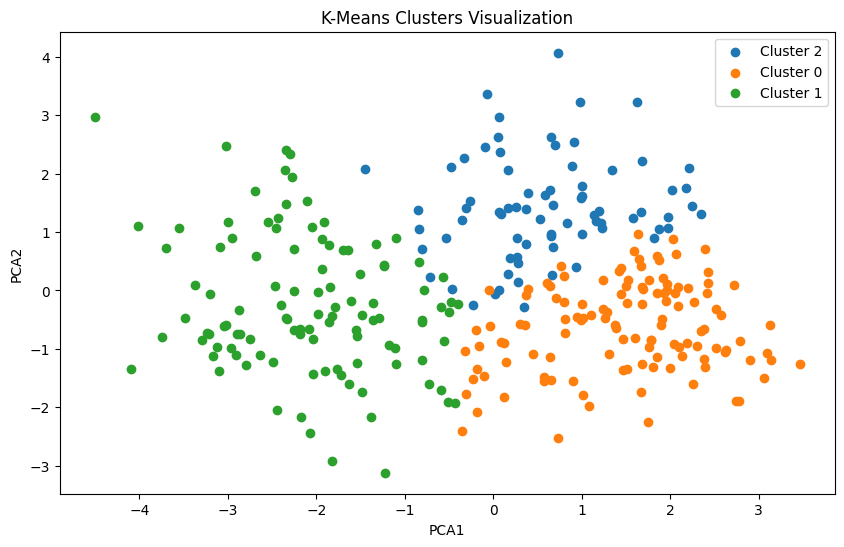

Number of points in each cluster:
Cluster
0    121
1    108
2     74
Name: count, dtype: int64


In [19]:
# Import necessary libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the dataset (replace 'heart.csv' with your actual dataset file)
df = pd.read_csv('heart.csv')

# Step 2: Scale the data for proper clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)  # Scale the numerical columns in the dataset

# Step 3: Perform K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)  # Choose 3 clusters as an example
df['Cluster'] = kmeans.fit_predict(scaled_data)  # Add cluster labels to the dataframe

# Step 4: Visualize the clusters
# Reduce data to 2 dimensions using PCA for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
df['PCA1'] = pca_data[:, 0]
df['PCA2'] = pca_data[:, 1]

# Plot the clusters
plt.figure(figsize=(10, 6))
for cluster in df['Cluster'].unique():  # Loop through each unique cluster
    cluster_data = df[df['Cluster'] == cluster]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'], label=f'Cluster {cluster}')

plt.title('K-Means Clusters Visualization')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.show()

# Step 5: Analyze cluster sizes
print("Number of points in each cluster:")
print(df['Cluster'].value_counts())


In [17]:
# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)  # Choose number of clusters (e.g., 3)
df['Cluster'] = kmeans.fit_predict(scaled_data)  # Assign cluster labels to each data point

# Check the first few rows to see clusters
print(df.head())


NameError: name 'scaled_data' is not defined

In [18]:
df['Cluster'] = kmeans.fit_predict(scaled_data)


NameError: name 'scaled_data' is not defined